# 4. Running a real NEURON simulation

Notebook 3 solved the *passive* cable equations directly. For active
conductances — real sodium/potassium channels, real action potentials — hand
the morphology to the [NEURON](https://neuron.yale.edu/) simulator.

`pynetrees.neuron_bridge` builds NEURON `Section` objects **directly in-process**.
There are no `.hoc` files, no subprocess, and no exchange folder: the MATLAB
T2N package needs all of that only because MATLAB has no direct NEURON binding,
and Python does.

## Installing NEURON

- **Linux / macOS:** `pip install neuron`
- **Windows:** there is *no* pip wheel. Install the official binary from
  [neuronsimulator.github.io](https://www.neuronsimulator.org/en/latest/install/install_instructions.html)
  and make sure it targets the same Python you're running here.

In [1]:
import numpy as np
import pynetrees as pt

import neuron
print("NEURON", neuron.__version__)

NEURON 9.0.0


## Building the model

`build_neuron_model` turns each *section* (the stretches between branch points,
i.e. `dissect_tree`'s output) into one NEURON `Section`, built from the real 3D
points so diameters taper exactly as in the morphology.

The passive properties come from the same `Ri`/`Gm`/`Cm` attributes used in
notebook 3.

In [2]:
tree = pt.repair_tree(pt.sample_tree())
tree.Ri, tree.Gm, tree.Cm = 100.0, 1 / 2500.0, 1.0

model = pt.build_neuron_model(tree)

print(f"{tree.n_nodes} tree nodes -> {len(model.sections)} NEURON sections")
total_seg = sum(sec.nseg for sec in model.sections)
print(f"total segments (compartments): {total_seg}")
print(f"segment counts chosen by NEURON's own d-lambda rule")

197 tree nodes -> 51 NEURON sections
total segments (compartments): 51
segment counts chosen by NEURON's own d-lambda rule


`model.loc(node)` maps any tree node index to the NEURON segment it lives in —
the bridge between the two worlds. Use it to attach anything NEURON provides.

In [3]:
plen = pt.Pvec_tree(tree, pt.len_tree(tree))
tips = np.flatnonzero(pt.T_tree(tree))
distal = int(tips[np.argmax(plen[tips])])
soma = 0

print(f"soma   node {soma:5d} -> NEURON segment {model.loc(soma)}")
print(f"distal node {distal:5d} -> NEURON segment {model.loc(distal)}")
print(f"   ({plen[distal]:.0f} um out along the tree)")

soma   node     0 -> NEURON segment sec0(0)
distal node   196 -> NEURON segment sec50(1)
   (143 um out along the tree)


## A passive run, cross-checked against `sse_tree`

Before trusting anything active, verify the passive case against the
independent analytic solver from notebook 3. Two completely different
implementations — an industry-standard simulator vs. our own sparse linear
algebra — should agree.

In [4]:
amp = 0.01   # nA
t, v = pt.run_current_clamp(model, at_node=soma, amp=amp,
                            delay=5, dur=3000, tstop=3000,
                            record_nodes=[soma, distal])

steady_neuron = v[soma][-1] - (-70.0)          # depolarisation from rest
steady_analytic = pt.sse_tree(tree, I=soma)[soma] * amp

print(f"NEURON   steady-state depolarisation at soma: {steady_neuron:.4f} mV")
print(f"sse_tree analytic prediction               : {steady_analytic:.4f} mV")
print(f"difference: {100*abs(steady_neuron-steady_analytic)/steady_analytic:.1f}%")

NEURON   steady-state depolarisation at soma: 0.7049 mV
sse_tree analytic prediction               : 0.6975 mV
difference: 1.1%


Close, but not identical — and the reason is worth understanding rather than
hand-waving. NEURON's `pt3dadd` **continuously tapers** diameter between
consecutive 3D points, while `sse_tree` treats each segment as a uniform
cylinder. They are two different (both valid) discretisations of the same
tapering cable, so they agree closely only when the taper is mild.

On a tree with *uniform* diameters — removing that ambiguity entirely — they
agree to ~1%. That check is in `tests/test_neuron_bridge.py`.

## Adding active conductances

`insert_mechanism` inserts any NEURON mechanism, optionally restricted to one
region. Here we make the whole cell excitable with Hodgkin-Huxley channels.

In [5]:
active = pt.build_neuron_model(tree)
pt.insert_mechanism(active, "hh")

# 2 nA -- this tree has a large membrane area, so it takes a healthy current
# to reach threshold; 0.5 nA only depolarises it a few mV without firing
t, v = pt.run_current_clamp(active, at_node=soma, amp=2.0,
                            delay=5, dur=40, tstop=60,
                            record_nodes=[soma, distal], v_init=-65.0)

overshoots = int(((v[soma][:-1] < 0) & (v[soma][1:] >= 0)).sum())
print(f"peak voltage at soma  : {v[soma].max():7.2f} mV")
print(f"peak voltage at distal: {v[distal].max():7.2f} mV")
print(f"upstrokes past 0 mV at soma: {overshoots}")

peak voltage at soma  :   46.81 mV
peak voltage at distal:   41.13 mV
upstrokes past 0 mV at soma: 5


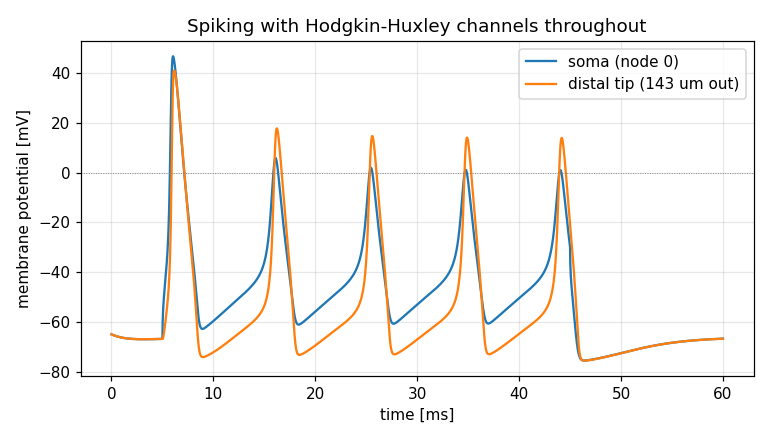

In [6]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t, v[soma], label=f"soma (node {soma})", lw=1.5)
ax.plot(t, v[distal], label=f"distal tip ({plen[distal]:.0f} um out)", lw=1.5)
ax.axhline(0, color="grey", lw=0.6, ls=":")
ax.set_xlabel("time [ms]"); ax.set_ylabel("membrane potential [mV]")
ax.set_title("Spiking with Hodgkin-Huxley channels throughout")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig("tut04_spikes.png", dpi=110); plt.close(fig)

from IPython.display import Image
Image("tut04_spikes.png")

Note the distal tip actually reaches a **higher** peak than the soma here.
That isn't a mistake: with Hodgkin-Huxley channels inserted uniformly, the thin
distal dendrite has a much higher input impedance and far less membrane load
than the soma, so once it is driven past threshold it produces a fuller spike.
A real model would use region-specific channel densities instead, which is
what the next section is about.

In [7]:
# the bundled sample has one region; with a granule cell you would write e.g.
#   pt.insert_mechanism(model, "hh",  region="soma")
#   pt.insert_mechanism(model, "pas", region="adendOML")
print("regions available on this tree:", list(active.region_sections))
for name, secs in active.region_sections.items():
    print(f"  {name!r}: {len(secs)} sections")

regions available on this tree: ['dendrite', 'subtree']
  'dendrite': 46 sections
  'subtree': 5 sections


## Going further with raw NEURON

`model.loc(node)` gives you a normal NEURON segment, so anything NEURON can do
is available — synapses, voltage clamps, custom mechanisms:

```python
from neuron import h

syn = h.Exp2Syn(model.loc(distal))
syn.tau1, syn.tau2, syn.e = 0.2, 2.5, 0.0

stim = h.NetStim(); stim.number = 5; stim.interval = 20; stim.start = 10
nc = h.NetCon(stim, syn); nc.weight[0] = 0.001

v_soma = h.Vector().record(model.loc(0)._ref_v)
h.finitialize(-70); h.continuerun(200)
```

**Next:** [`05_populations_and_stats.ipynb`](05_populations_and_stats.ipynb)